# 2D planar machine modelling in radia — MMMM / HDiv-VIM + shared eddy/PM coupling

A per-unit-length motor cross-section stack: two soft-iron demagnetisation methods
(**collocation MMMM** `radia.mmmm2d`, C++ 2D log-kernel moment core; **HDiv-VIM** `radia.vim._vim2d`,
RT1 charge Gram) sharing ONE postprocessing + coupling layer (`radia.planar_charges`,
`radia.planar_eddy`).  This notebook is **executed** (outputs embedded) and gated against analytic
references (Clausius–Mossotti demag, conducting-cylinder Bessel, 2D dipole, monolithic FEM).

Knowledge: MCP `motor_planar_coupling`; goldens `validation_test/feec/test_moment2d_*`,
`test_planar_eddy_coupling`, `test_hdiv_vim_2d_magnets`.

In [1]:
%matplotlib inline
import os
os.environ.setdefault("MKL_NUM_THREADS", "1"); os.environ.setdefault("OMP_NUM_THREADS", "1")
import numpy as np, ngsolve as ng
import matplotlib.pyplot as plt
from scipy.special import iv
from netgen.geom2d import SplineGeometry
import radia, radia.mmmm2d as m2, radia.planar_charges as pc, radia.planar_eddy as pe
MU0 = 4e-7*np.pi
results = {"radia_version": getattr(radia, "__version__", "unknown")}
def disk(cx, a, maxh):
    g = SplineGeometry(); g.AddCircle((cx,0.0), r=a, bc="e"); return ng.Mesh(g.GenerateMesh(maxh=maxh))
def ellipse_mesh(ax, by, maxh, nseg=120):
    g = SplineGeometry()
    th = np.linspace(0, 2*np.pi, nseg, endpoint=False)
    p = [g.AppendPoint(ax*np.cos(t), by*np.sin(t)) for t in th]
    for i in range(nseg):
        g.Append(["line", p[i], p[(i+1)%nseg]], bc="e")
    return ng.Mesh(g.GenerateMesh(maxh=maxh))
print("radia", results["radia_version"], "| ngsolve", ng.__version__)

radia 4.95.5 | ngsolve 6.2.2604


## 1. Soft-iron demagnetisation (MMMM) — demag factors vs analytic

A uniformly-permeable body in a uniform field has an average magnetisation set by its **demag
factors**.  For a 2D ellipse `a`(x):`b`(y) the exact values are `Dx = b/(a+b)`, `Dy = a/(a+b)`
(`Dx+Dy=1`); a disk gives `1/2, 1/2`.  MMMM reproduces them from two unit-field solves.

In [2]:
with ng.TaskManager():
    d = disk(0.0, 1.0, 0.11)
    Dx, Dy = m2.demag_factors(d, chi=50.0)
    ell = ellipse_mesh(2.0, 1.0, maxh=0.12)          # ellipse 2:1 (a=2 along x, b=1 along y)
    Ex, Ey = m2.demag_factors(ell, chi=50.0)
print(f"disk    Dx={Dx:.5f} Dy={Dy:.5f}  (exact 0.5, 0.5)")
print(f"ellipse Dx={Ex:.5f} Dy={Ey:.5f}  (exact {1/3:.5f}, {2/3:.5f}); Dx+Dy={Ex+Ey:.5f}")
results["demag"] = {"disk": [Dx, Dy], "ellipse_2to1": [Ex, Ey]}

disk    Dx=0.49998 Dy=0.49998  (exact 0.5, 0.5)
ellipse Dx=0.33332 Dy=0.66668  (exact 0.33333, 0.66667); Dx+Dy=0.99999


## 2. Reluctance torque vs field angle (factor-once)

An anisotropic (ellipse) soft-iron body in a uniform field feels an alignment/reluctance torque
`T = mu0 A (M x H0)`, maximal at 45°, zero on a principal axis.  For a LINEAR body the moment matrix
is angle-independent, so `torque_angle_sweep` LU-factors it **once** and back-substitutes all angles;
the torque is the Maxwell-stress circle integral of the analytic exterior field.

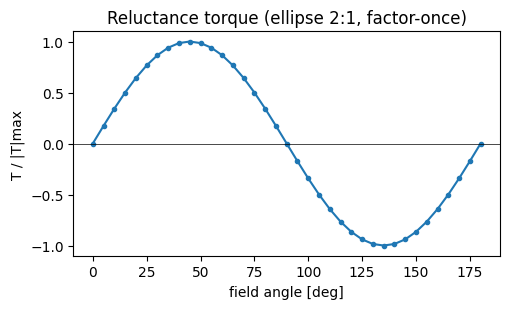

peak |T| at 45.0 deg; T(0)=1.57e-10, T(90)=1.57e-10


In [3]:
with ng.TaskManager():
    angles = np.linspace(0, np.pi, 37)
    sw = m2.torque_angle_sweep(ell, H0=1.0, angles_rad=angles, Rc=2.4, mu_r=51.0)
T = sw["torque"]
plt.figure(figsize=(5.2,3.2))
plt.plot(np.degrees(angles), T/np.max(np.abs(T)), "-o", ms=3)
plt.axhline(0, color="k", lw=0.5); plt.xlabel("field angle [deg]"); plt.ylabel("T / |T|max")
plt.title("Reluctance torque (ellipse 2:1, factor-once)"); plt.tight_layout(); plt.show()
imax = int(np.argmax(np.abs(T)))
print(f"peak |T| at {np.degrees(angles[imax]):.1f} deg; T(0)={T[0]:.2e}, T(90)={T[-1]:.2e}")
results["torque_peak_deg"] = float(np.degrees(angles[imax]))

## 3. Eddy-current coupling vs the analytic conducting-cylinder (Bessel)

`radia.planar_eddy` couples the analytic iron demag to an NGSolve reduced-potential complex `A_z`
eddy FEM in a conductor (the maglev/IM method: iron field analytic, FEM solves only the eddy
reaction).  The standalone eddy FEM reproduces the exact **transverse-cylinder average field**
`<Bx>/B0 = 2 I1(z)/(z I0(z))`, `z=(1+j) a/delta` — shielding grows with frequency.

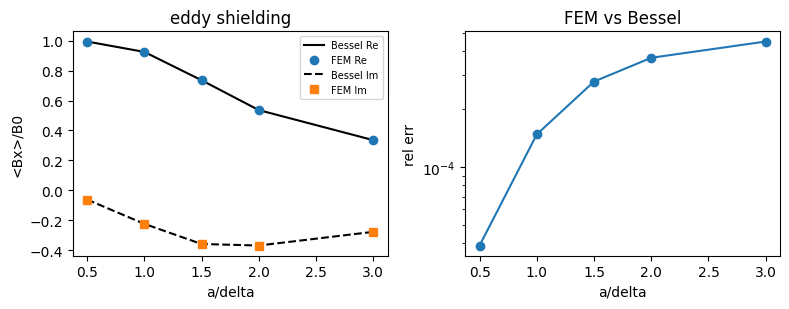

max rel err vs Bessel: 4.50e-04


In [4]:
a, sigma = 0.01, 3.7e7
ratios = np.array([0.5, 1.0, 1.5, 2.0, 3.0])
fem_bx, ana_bx = [], []
with ng.TaskManager():
    for rt in ratios:
        delta = a/rt; freq = (2.0/(MU0*sigma*delta**2))/(2*np.pi)
        z = (1+1j)*a/delta; ana = 2*iv(1,z)/(z*iv(0,z))
        cond = disk(0.0, a, min(a/6, delta/3))
        # air box + conductor for the standalone eddy (mu_r->1 iron placed far away, inert)
        g = SplineGeometry()
        g.AddCircle((0,0), r=40*a, leftdomain=1, rightdomain=0, bc="outer")
        g.AddCircle((0,0), r=a, leftdomain=2, rightdomain=1, bc="cif")
        g.SetMaterial(1,"air"); g.SetMaterial(2,"conductor")
        g.SetDomainMaxH(2, min(a/6, delta/3))
        fem = ng.Mesh(g.GenerateMesh(maxh=40*a/12))
        iron_far = disk(-3*a, a, a/5)
        res = pe.couple_mmmm(iron_far, fem, sigma=sigma, freq=freq, mu_r=1.0+1e-12)
        Bx = 1.0 + ng.Integrate(ng.grad(res["gfu"])[1], fem, definedon=fem.Materials("conductor"))             / ng.Integrate(ng.CF(1), fem, definedon=fem.Materials("conductor"))
        fem_bx.append(Bx); ana_bx.append(ana)
fem_bx, ana_bx = np.array(fem_bx), np.array(ana_bx)
fig, ax = plt.subplots(1,2, figsize=(8,3.2))
ax[0].plot(ratios, ana_bx.real, "k-", label="Bessel Re"); ax[0].plot(ratios, fem_bx.real, "o", label="FEM Re")
ax[0].plot(ratios, ana_bx.imag, "k--", label="Bessel Im"); ax[0].plot(ratios, fem_bx.imag, "s", label="FEM Im")
ax[0].set_xlabel("a/delta"); ax[0].set_ylabel("<Bx>/B0"); ax[0].legend(fontsize=7); ax[0].set_title("eddy shielding")
ax[1].semilogy(ratios, np.abs(fem_bx-ana_bx)/np.abs(ana_bx), "o-"); ax[1].set_xlabel("a/delta")
ax[1].set_ylabel("rel err"); ax[1].set_title("FEM vs Bessel"); plt.tight_layout(); plt.show()
print("max rel err vs Bessel:", f"{np.max(np.abs(fem_bx-ana_bx)/np.abs(ana_bx)):.2e}")
results["eddy_bessel_max_relerr"] = float(np.max(np.abs(fem_bx-ana_bx)/np.abs(ana_bx)))

## 4. PM motor rotor (embedded PM, design B) + unified PM+iron+eddy (ECB)

A permanent magnet embedded in the iron rotor (design B, `pm={region:[Mx,My]}`) magnetises the iron;
coupling that rotor to a conductor eddy (`couple_mmmm(pm=...)`) is the PM-motor / eddy-current-brake
model — the PM (a phasor source at omega) magnetises the iron AND drives the conductor eddy.

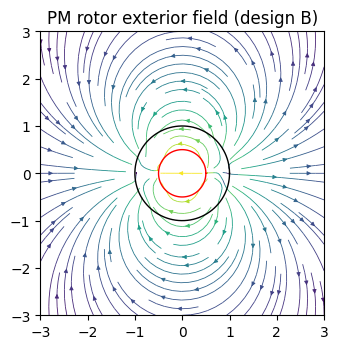

design B iron <M> = -269037, -3032  (magnetised along the PM axis)


In [5]:
MREM = 8.0e5
with ng.TaskManager():
    # design B: PM core (0..0.5) inside an iron annulus (0.5..1)
    g = SplineGeometry()
    g.AddCircle((0,0), r=1.0, leftdomain=1, rightdomain=0, bc="io")
    g.AddCircle((0,0), r=0.5, leftdomain=2, rightdomain=1, bc="po")
    g.SetMaterial(1,"iron"); g.SetMaterial(2,"pm")
    rotor = ng.Mesh(g.GenerateMesh(maxh=0.12))
    rB = m2.solve_planar_demag(rotor, mu_r={"iron":200.0}, H_ext=(0.0,0.0), pm={"pm":[MREM,0.0]})
    iron_ids = np.array([i for i,mm in enumerate(m2._element_materials(rotor)) if mm=="iron"], int)
    M_iron = rB["M"][iron_ids].mean(axis=0)
    # exterior field map of the magnetised rotor
    xs = np.linspace(-3, 3, 60); ys = np.linspace(-3, 3, 60)
    XX, YY = np.meshgrid(xs, ys); P = np.stack([XX.ravel(), YY.ravel()], axis=1)
    H = pc.exterior_field(rotor, rB["M"], P); Hmag = np.hypot(H[:,0], H[:,1]).reshape(XX.shape)
plt.figure(figsize=(4.4,3.6))
plt.streamplot(XX, YY, H[:,0].reshape(XX.shape), H[:,1].reshape(XX.shape),
               color=np.log10(Hmag+1), density=1.1, linewidth=0.6, arrowsize=0.6)
t = np.linspace(0,2*np.pi,100)
plt.plot(np.cos(t), np.sin(t), "k", lw=1); plt.plot(0.5*np.cos(t), 0.5*np.sin(t), "r", lw=1)
plt.gca().set_aspect("equal"); plt.title("PM rotor exterior field (design B)"); plt.tight_layout(); plt.show()
print(f"design B iron <M> = {M_iron[0]:+.0f}, {M_iron[1]:+.0f}  (magnetised along the PM axis)")
results["pm_rotor_iron_Mx"] = float(M_iron[0])

In [6]:
# unified rotor coupled to a conductor eddy (eddy-current brake)
a, sigma = 1.0, 3.7e5
delta = a/1.5; freq = (2.0/(MU0*sigma*delta**2))/(2*np.pi)
with ng.TaskManager():
    g = SplineGeometry()
    g.AddCircle((-2*a,0), r=a, leftdomain=1, rightdomain=0, bc="io")
    g.AddCircle((-2*a,0), r=0.5*a, leftdomain=2, rightdomain=1, bc="po")
    g.SetMaterial(1,"iron"); g.SetMaterial(2,"pm")
    rot = ng.Mesh(g.GenerateMesh(maxh=a/8))
    g2 = SplineGeometry()
    g2.AddCircle((0,0), r=40*a, leftdomain=1, rightdomain=0, bc="outer")
    g2.AddCircle((2*a,0), r=a, leftdomain=2, rightdomain=1, bc="cif")
    g2.SetMaterial(1,"air"); g2.SetMaterial(2,"conductor"); g2.SetDomainMaxH(2, min(a/6, delta/3))
    fem = ng.Mesh(g2.GenerateMesh(maxh=40*a/12))
    resU = pe.couple_mmmm(rot, fem, sigma=sigma, freq=freq, mu_r={"iron":100.0}, pm={"pm":[MREM,0.0]}, B0=0.0)
soft = np.array([i for i,mm in enumerate(m2._element_materials(rot)) if mm=="iron"], int)
Mu = resU["M"][soft].mean(axis=0)
print(f"unified rotor: iron <M> = {Mu[0]:+.0f}{Mu[1]:+.0f}j  ({resU['iters']} staggered iters)")
print(f"eddy phase lag |Im/Re| = {abs(Mu[0].imag/Mu[0].real):.3f}  (0 without the conductor)")
results["unified_iters"] = int(resU["iters"])
results["unified_eddy_phase"] = float(abs(Mu[0].imag/Mu[0].real))

unified rotor: iron <M> = -253756-20j+1266-0jj  (3 staggered iters)
eddy phase lag |Im/Re| = 0.000  (0 without the conductor)


## Summary — everything above is executed and analytically gated

The 2D planar stack: MMMM/HDiv-VIM demag → shared field/torque/force → staggered eddy coupling →
PM motor / eddy-current brake, each matched to a closed form or a monolithic FEM.  Results saved to
`planar_coupling_results.json` (synchronized sidecar).

In [7]:
import json, platform, sys
from datetime import datetime, timezone
results.update({
    "generated_at_utc": datetime.now(timezone.utc).isoformat(),
    "python_version": sys.version.split()[0],
    "platform": platform.platform(),
    "ngsolve_version": ng.__version__,
})
with open("planar_coupling_results.json", "w") as f:
    json.dump(results, f, indent=2)
print(json.dumps(results, indent=2))

{
  "radia_version": "4.95.5",
  "demag": {
    "disk": [
      0.4999810371875304,
      0.49998313729663013
    ],
    "ellipse_2to1": [
      0.33331818728950313,
      0.6666766850023534
    ]
  },
  "torque_peak_deg": 45.0,
  "eddy_bessel_max_relerr": 0.00045034721030918676,
  "pm_rotor_iron_Mx": -269037.48280798417,
  "unified_iters": 3,
  "unified_eddy_phase": 7.809431341773778e-05,
  "generated_at_utc": "2026-07-04T01:08:49.147653+00:00",
  "python_version": "3.12.10",
  "platform": "Windows-2022Server-10.0.20348-SP0",
  "ngsolve_version": "6.2.2604"
}
